In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

prices = pd.read_csv(
    "./data/etf_prices_daily.csv",
    index_col=0,
    parse_dates=True
)

monthly_prices = prices.resample("ME").last()
monthly_returns = monthly_prices.pct_change()

In [3]:
def run_momentum_backtest(
    monthly_prices,
    top_n=3,
    lookback_months=12,
    skip_months=1,
    cost_per_turnover=0.001
):
    monthly_returns = monthly_prices.pct_change()

    signal = (
        monthly_prices.shift(skip_months)
        / monthly_prices.shift(lookback_months)
    ) - 1

    weights = pd.DataFrame(
        0.0,
        index=signal.index,
        columns=signal.columns
    )

    for date in signal.index:
        scores = signal.loc[date].dropna()

        if len(scores) >= top_n:
            selected = scores.nlargest(top_n).index
            weights.loc[date, selected] = 1 / top_n

    gross_returns = (
        weights.shift(1) * monthly_returns
    ).sum(axis=1)

    turnover = weights.diff().abs().sum(axis=1) / 2
    transaction_costs = turnover * cost_per_turnover
    net_returns = gross_returns - transaction_costs

    return net_returns.dropna(), weights, turnover

In [4]:
net_returns, weights, turnover = run_momentum_backtest(
    monthly_prices=monthly_prices,
    top_n=3,
    lookback_months=12,
    skip_months=1,
    cost_per_turnover=0.001
)

benchmark_returns = monthly_returns.mean(axis=1)

all_results = pd.concat(
    [
        net_returns.rename("Momentum Strategy (Net)"),
        benchmark_returns.rename("Equal-Weight Benchmark")
    ],
    axis=1
).dropna()

all_results.head()

,Momentum Strategy (Net),Equal-Weight Benchmark
Date,,
2015-02-28,0.0,0.005116
2015-03-31,0.0,-0.002479
2015-04-30,0.0,-0.015165
2015-05-31,0.0,0.006085
2015-06-30,0.0,-0.023315


In [7]:
in_sample = all_results.loc["2010-01-01":"2018-12-31"]
out_of_sample = all_results.loc["2019-01-01":]

print("In-sample period:")
print(in_sample.index.min().date(), "to", in_sample.index.max().date())

print("\nOut-of-sample period:")
print(
    out_of_sample.index.min().date(),
    "to",
    out_of_sample.index.max().date()
)

In-sample period:
2015-02-28 to 2018-12-31

Out-of-sample period:
2019-01-31 to 2026-07-31


In [9]:
def performance_metrics(returns, periods_per_year=12):
    returns = returns.dropna()

    equity = (1 + returns).cumprod()
    years = len(returns) / periods_per_year

    total_return = equity.iloc[-1] - 1
    annualised_return = equity.iloc[-1] ** (1 / years) - 1
    annualised_volatility = returns.std() * np.sqrt(periods_per_year)

    sharpe_ratio = (
        returns.mean() / returns.std()
    ) * np.sqrt(periods_per_year)

    drawdown = equity / equity.cummax() - 1
    max_drawdown = drawdown.min()

    return pd.Series({
        "Total Return": total_return,
        "Annualised Return": annualised_return,
        "Annualised Volatility": annualised_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown
    })

In [10]:
validation_metrics = pd.DataFrame({
    "In-sample Momentum": performance_metrics(
        in_sample["Momentum Strategy (Net)"]
    ),
    "In-sample Benchmark": performance_metrics(
        in_sample["Equal-Weight Benchmark"]
    ),
    "Out-of-sample Momentum": performance_metrics(
        out_of_sample["Momentum Strategy (Net)"]
    ),
    "Out-of-sample Benchmark": performance_metrics(
        out_of_sample["Equal-Weight Benchmark"]
    )
})

validation_metrics

,In-sample Momentum,In-sample Benchmark,Out-of-sample Momentum,Out-of-sample Benchmark
Total Return,0.191341,0.197884,1.925974,1.488288
Annualised Return,0.045715,0.047179,0.152089,0.127734
Annualised Volatility,0.112806,0.079643,0.137572,0.137568
Sharpe Ratio,0.453156,0.618924,1.103042,0.946327
Maximum Drawdown,-0.174565,-0.089788,-0.248452,-0.250078


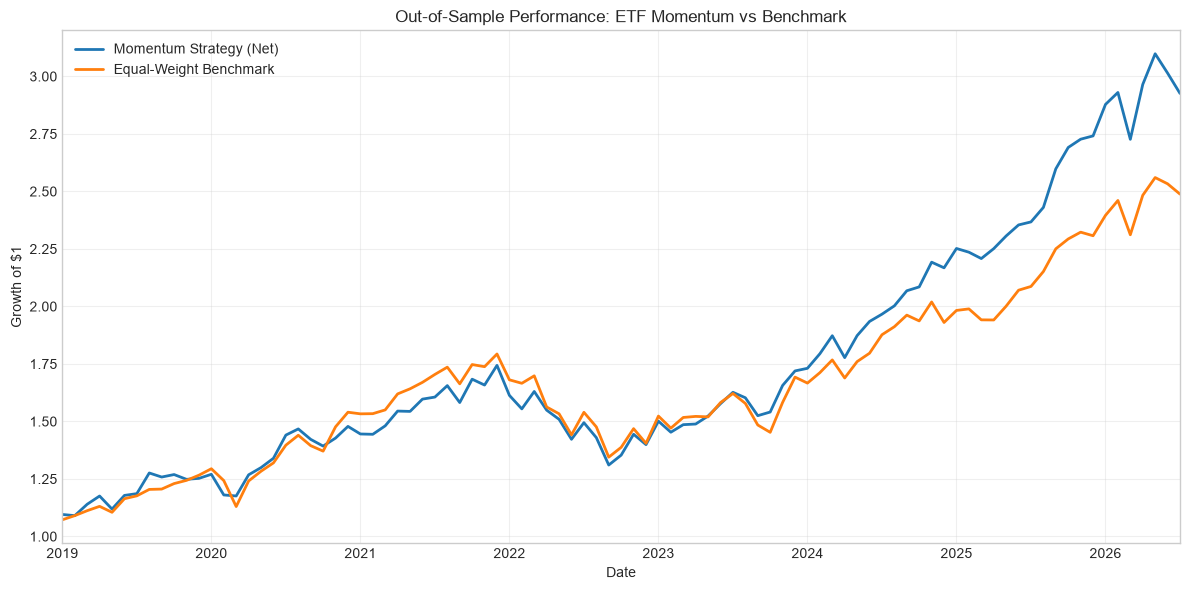

In [12]:
oos_equity = (1 + out_of_sample).cumprod()

oos_equity.plot(figsize=(12, 6), linewidth=2)

plt.title("Out-of-Sample Performance: ETF Momentum vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "./figures/out_of_sample_equity_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [14]:
validation_metrics.to_csv(
    "./data/in_sample_out_of_sample_metrics.csv"
)

out_of_sample.to_csv(
    "./data/out_of_sample_monthly_returns.csv"
)

print("Out-of-sample results saved.")

Out-of-sample results saved.
